# Sections 4 & 5 — Demand Gap and Communication Opportunity
**Person C: Use Case Analyst**

Sections of the GivingTuesday 2024 AI Readiness Survey analysis (n = 930 nonprofits).

In [1]:
import pandas as pd
import matplotlib.pyplot as pyplot
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
import ast

In [2]:
normalized_df = pd.read_csv('../ai_survey_normalized_clustering_data.csv')
survey_df     = pd.read_csv('../ai_survey_results_2024_n=930.csv')
print(f"Loaded: normalized_df {normalized_df.shape}, survey_df {survey_df.shape}")

Loaded: normalized_df (930, 38), survey_df (930, 48)


## Step 0: Data Cleaning
Shared cleaning pipeline (mirrors `main.ipynb`).

In [3]:
# Drop non_org_type (96% null) and strip whitespace across all string columns
survey_df = survey_df.drop(columns=['non_org_type'], errors='ignore')
for col in survey_df.select_dtypes(include='object').columns:
    survey_df[col] = survey_df[col].str.strip()

In [4]:
LIST_COLS = ['ai_use', 'ai_want', 'ai_risk', 'data_kinds']

def parse_list_col(val):
    if pd.isna(val):
        return []
    val = val.replace('\xa0', ' ')
    try:
        items = ast.literal_eval(val)
        return [s.strip() for s in items if isinstance(s, str) and s.strip()]
    except Exception:
        return [val.strip()] if val.strip() else []

for col in LIST_COLS:
    if col in survey_df.columns:
        survey_df[col] = survey_df[col].apply(parse_list_col)

In [5]:
# Drop rows where org_opentext is too short to be usable (< 5 chars)
survey_df = survey_df[
    survey_df['org_opentext'].isna() | (survey_df['org_opentext'].str.len() >= 5)
]

# Impute person_ai_comfort_raw from normalized person_ai_comfort (scale: 0–10)
mask = survey_df['person_ai_comfort_raw'].isna() & survey_df['person_ai_comfort'].notna()
survey_df.loc[mask, 'person_ai_comfort_raw'] = (
    survey_df.loc[mask, 'person_ai_comfort'] * 10
).round()

# Fill missing region values
survey_df['continent']           = survey_df['continent'].fillna('Unknown')
survey_df['global_north_south']  = survey_df['global_north_south'].fillna('Unknown')

# Merge survey and normalized datasets on index
merged_df = survey_df.merge(
    normalized_df, left_index=True, right_index=True, suffixes=('', '_norm')
)
print(f"Step 0 complete. merged_df: {merged_df.shape}")

Step 0 complete. merged_df: (906, 85)


In [6]:
# Shared cluster color palette — define once, use everywhere
CLUSTER_PALETTE = {
    1:  '#2196F3',   # AI Consumers  — blue
    0:  '#FFC107',   # Late Adopters — amber
    -1: '#F44336',   # AI Skeptics   — red
}
CLUSTER_LABELS = {
    1:  'AI Consumers',
    0:  'Late Adopters',
    -1: 'AI Skeptics',
}
ORG_SIZE_ORDER = ['0-5', '6-15', '16-30', '31-60', '61-120', '121+']

## Section 4 — Demand Gap

**Goal:** Show where nonprofits want more AI support than they currently have.

- Compare current AI use (`[U]*`) vs. desired AI use (`[W]*`) for four task categories:
  Drafting, Organizing, Interpreting, and Predicting.
- Each column is a binary 0/1 flag; aggregate = % of nonprofits who use/want AI for that task.

In [7]:
# Map each task category to its current-use and desired-use binary columns
TASK_CATEGORIES = {
    'Drafting':     ('[U] Generat',   '[W] Generat'),
    'Organizing':   ('[U] Organi',    '[W] Organi'),
    'Interpreting': ('[U] Interpret', '[W] Interpret'),
    'Predicting':   ('[U] Predict',   '[W] Predict'),
}

rows = []
for task, (use_col, want_col) in TASK_CATEGORIES.items():
    rows.append({
        'Task':             task,
        'Current Use (%)':  normalized_df[use_col].mean()  * 100,
        'Desired Use (%)':  normalized_df[want_col].mean() * 100,
    })

task_df = pd.DataFrame(rows)
task_df['Demand Gap (pp)'] = task_df['Desired Use (%)'] - task_df['Current Use (%)']
print(task_df.round(1).to_string(index=False))

        Task  Current Use (%)  Desired Use (%)  Demand Gap (pp)
    Drafting             53.9             54.9              1.1
  Organizing             19.1             60.3             41.2
Interpreting             15.3             49.9             34.6
  Predicting             11.2             51.7             40.5


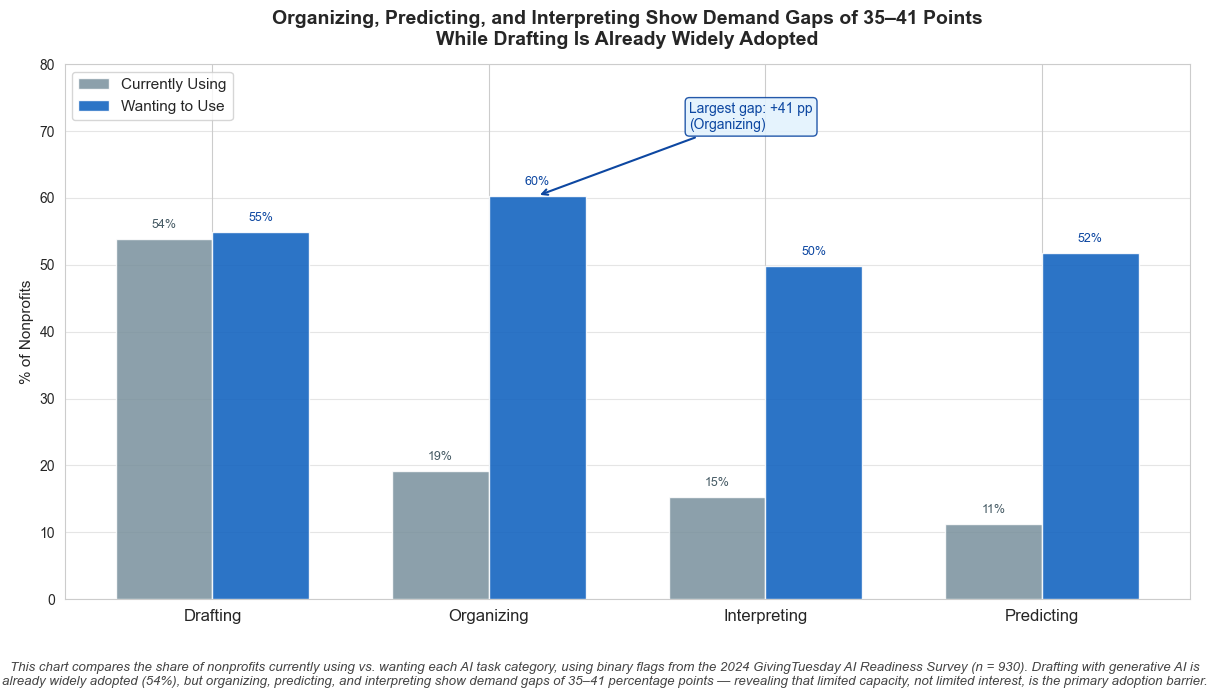

In [8]:
sns.set_style('whitegrid')
fig, ax = pyplot.subplots(figsize=(12, 7))

tasks  = task_df['Task'].tolist()
x      = np.arange(len(tasks))
width  = 0.35

bars_cur = ax.bar(
    x - width / 2, task_df['Current Use (%)'], width,
    label='Currently Using', color='#78909C', alpha=0.85, zorder=3
)
bars_des = ax.bar(
    x + width / 2, task_df['Desired Use (%)'], width,
    label='Wanting to Use',  color='#1565C0', alpha=0.90, zorder=3
)

ax.set_title(
    "Organizing, Predicting, and Interpreting Show Demand Gaps of 35–41 Points\n"
    "While Drafting Is Already Widely Adopted",
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=12)
ax.set_ylabel('% of Nonprofits', fontsize=11)
ax.set_ylim(0, 80)
ax.legend(fontsize=11, loc='upper left')
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

# Label bars
for bar in bars_cur:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1.2, f'{h:.0f}%',
            ha='center', va='bottom', fontsize=9, color='#455A64')
for bar in bars_des:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1.2, f'{h:.0f}%',
            ha='center', va='bottom', fontsize=9, color='#0D47A1')

# Callout: Organizing has the largest demand gap
org_idx  = task_df[task_df['Task'] == 'Organizing'].index[0]
gap_val  = task_df.loc[org_idx, 'Demand Gap (pp)']
des_val  = task_df.loc[org_idx, 'Desired Use (%)']
callout_x = x[org_idx] + width / 2
ax.annotate(
    f"Largest gap: +{gap_val:.0f} pp\n(Organizing)",
    xy=(callout_x, des_val),
    xytext=(callout_x + 0.55, des_val + 10),
    fontsize=10, color='#0D47A1',
    arrowprops=dict(arrowstyle='->', color='#0D47A1', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', fc='#E3F2FD', ec='#0D47A1', alpha=0.9)
)

pyplot.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(
    0.5, 0.01,
    "This chart compares the share of nonprofits currently using vs. wanting each AI task "
    "category, using binary flags from the 2024 GivingTuesday AI Readiness Survey (n = 930). "
    "Drafting with generative AI is already widely adopted (54%), but organizing, predicting, "
    "and interpreting show demand gaps of 35–41 percentage points — revealing that limited "
    "capacity, not limited interest, is the primary adoption barrier.",
    ha='center', va='bottom', fontsize=9.5, color='#444', style='italic',
    wrap=True
)
pyplot.show()

## Section 5 — Communication Opportunity

**Goal:** Identify where AI can reduce donor communication burden most clearly for smaller nonprofits.

- Filter to small nonprofits (`org_small_med_large == 0`, i.e., 0–15 staff).
- Rank top desired AI use cases (`[W]*`) by demand among small orgs.
- Map top use cases to donor communication workflows.
- **Output 1:** Grouped bar chart — desired use cases × org size tier.
- **Output 2:** 2×2 matrix — staffing capacity (x) vs. communication burden (y).
  AI is most useful in the high-burden, low-capacity (upper-left) quadrant.

In [9]:
# Org-size tiers from normalized dataset
small_df = normalized_df[normalized_df['org_small_med_large'] == 0.0]   # 0–15 staff
med_df   = normalized_df[normalized_df['org_small_med_large'] == 0.5]   # 16–30 staff
large_df = normalized_df[normalized_df['org_small_med_large'] == 1.0]   # 30+ staff
print(f"Small: {len(small_df)}  Medium: {len(med_df)}  Large: {len(large_df)}")

# [W]* columns mapped to readable donor-workflow labels (excludes Other / Don't know)
W_COLS = ['[W] Ask', '[W] Assist', '[W] Generat', '[W] Interpret',
          '[W] Organi', '[W] Predict', '[W] Translat']
W_LABELS = {
    '[W] Ask':       'Chatbot / Q&A',
    '[W] Assist':    'Virtual Assistant',
    '[W] Generat':   'Drafting / GenAI',
    '[W] Interpret': 'Interpreting Data',
    '[W] Organi':    'Organizing',
    '[W] Predict':   'Predicting Outcomes',
    '[W] Translat':  'Translation',
}

# Rank by small-org demand; keep top 5
small_demand = small_df[W_COLS].mean().sort_values(ascending=False)
TOP_N     = 5
top_cols  = small_demand.index[:TOP_N].tolist()
top_labels = [W_LABELS[c] for c in top_cols]

print("\nTop desired use cases among small orgs:")
print((small_demand * 100).round(1).to_string())

Small: 586  Medium: 214  Large: 125

Top desired use cases among small orgs:
[W] Organi       56.7
[W] Generat      53.2
[W] Assist       48.8
[W] Predict      44.0
[W] Interpret    43.5
[W] Ask          35.2
[W] Translat     35.0


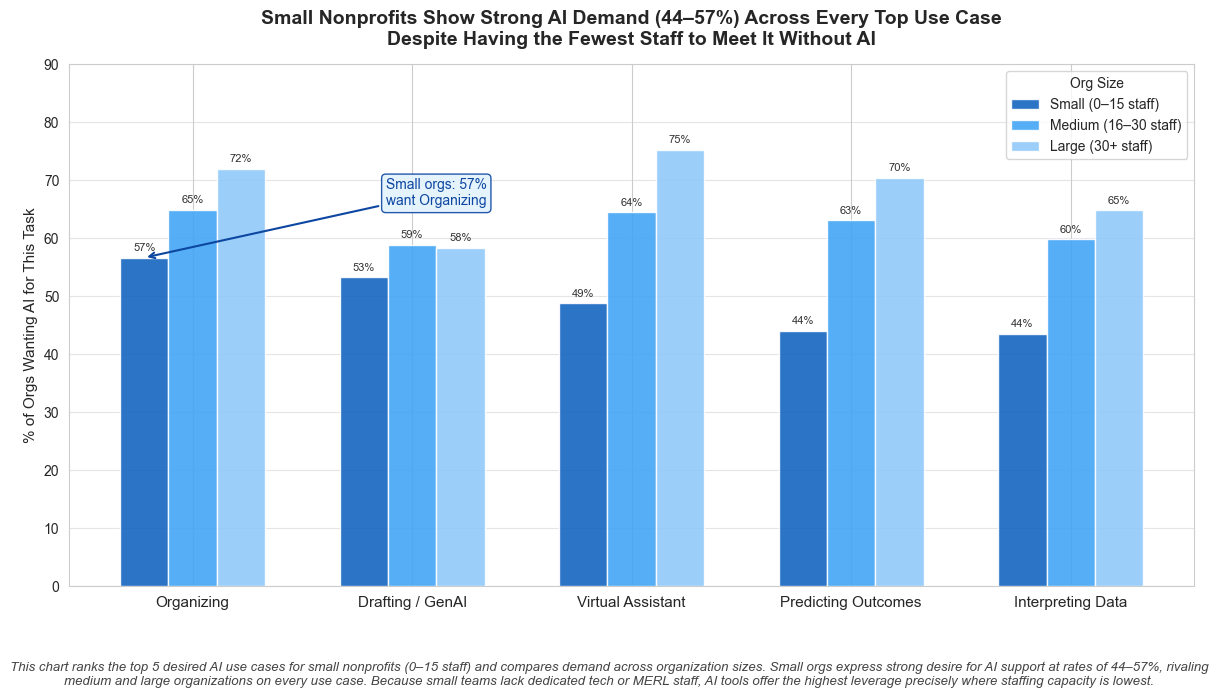

In [10]:
# --- Chart 1: Desired AI Use Cases by Org Size ---

demand_by_size = pd.DataFrame({
    'Small\n(0–15 staff)':   small_df[top_cols].mean() * 100,
    'Medium\n(16–30 staff)': med_df[top_cols].mean()   * 100,
    'Large\n(30+ staff)':    large_df[top_cols].mean() * 100,
}).T  # rows = size tiers, cols = use cases

size_colors = ['#1565C0', '#42A5F5', '#90CAF9']

fig, ax = pyplot.subplots(figsize=(12, 7))
sns.set_style('whitegrid')

n_groups = len(top_cols)
x        = np.arange(n_groups)
width    = 0.22

for i, (size_label, color) in enumerate(zip(demand_by_size.index, size_colors)):
    offset = (i - 1) * width
    bars = ax.bar(
        x + offset, demand_by_size.loc[size_label], width,
        label=size_label.replace('\n', ' '), color=color, alpha=0.9, zorder=3
    )
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8, f'{h:.0f}%',
                ha='center', va='bottom', fontsize=8, color='#333')

ax.set_title(
    "Small Nonprofits Show Strong AI Demand (44–57%) Across Every Top Use Case\n"
    "Despite Having the Fewest Staff to Meet It Without AI",
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xticks(x)
ax.set_xticklabels(top_labels, fontsize=11)
ax.set_ylabel('% of Orgs Wanting AI for This Task', fontsize=11)
ax.set_ylim(0, 90)
ax.legend(title='Org Size', fontsize=10, title_fontsize=10, loc='upper right')
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

# Callout: small orgs' top desire is Organizing (56.7%)
top_col_idx = 0  # Organizing is index 0 after sorting by small demand
peak_small  = small_df[top_cols[top_col_idx]].mean() * 100
callout_x   = x[top_col_idx] - width  # small org bar x position
ax.annotate(
    f"Small orgs: {peak_small:.0f}%\nwant {top_labels[top_col_idx]}",
    xy=(callout_x, peak_small),
    xytext=(callout_x + 1.1, peak_small + 9),
    fontsize=10, color='#0D47A1',
    arrowprops=dict(arrowstyle='->', color='#0D47A1', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', fc='#E3F2FD', ec='#0D47A1', alpha=0.9)
)

pyplot.tight_layout(rect=[0, 0.10, 1, 1])
fig.text(
    0.5, 0.01,
    "This chart ranks the top 5 desired AI use cases for small nonprofits (0–15 staff) "
    "and compares demand across organization sizes. Small orgs express strong desire for AI "
    "support at rates of 44–57%, rivaling medium and large organizations on every use case. "
    "Because small teams lack dedicated tech or MERL staff, AI tools offer the highest "
    "leverage precisely where staffing capacity is lowest.",
    ha='center', va='bottom', fontsize=9.5, color='#444', style='italic',
    wrap=True
)
pyplot.show()

              Use Case  Staffing Capacity (%)  Communication Burden (%)
0           Organizing                   16.4                      56.7
1     Drafting / GenAI                   15.3                      53.2
2    Virtual Assistant                   17.4                      48.8
3  Predicting Outcomes                   20.8                      44.0
4    Interpreting Data                   19.3                      43.5


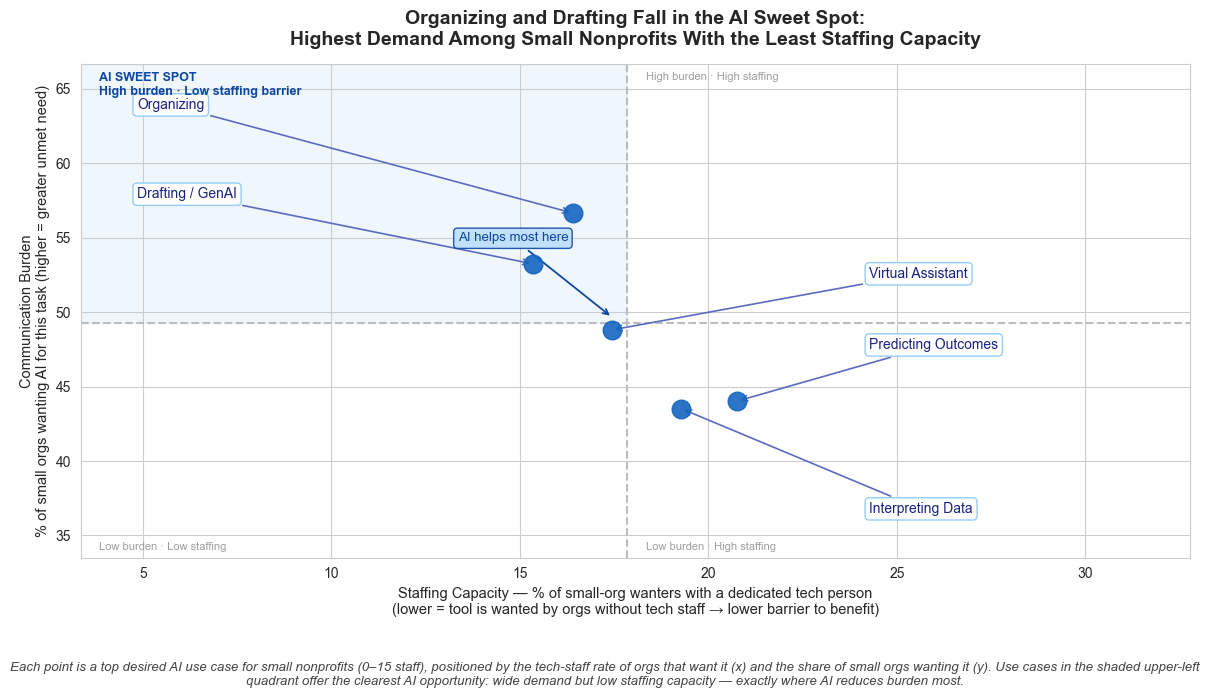

In [11]:
# --- Chart 2: 2×2 Matrix — Staffing Capacity vs. Communication Burden ---
#
# For each top use case among small orgs:
#   x = Staffing Capacity: % of small-org wanters who have a tech person
#       Lower x → wanted by orgs without tech staff → lower implementation barrier
#   y = Communication Burden: % of small orgs wanting this use case
#       Higher y → broader unmet need → higher priority for AI support
#
# AI Sweet Spot = upper-left quadrant (high burden, low staffing barrier)

matrix_rows = []
for col in top_cols:
    wanters = small_df[small_df[col] == 1]
    capacity = wanters['tech_person'].mean() * 100 if len(wanters) > 0 else 0
    burden   = small_df[col].mean() * 100
    matrix_rows.append({
        'Use Case':                W_LABELS[col],
        'Staffing Capacity (%)':   capacity,
        'Communication Burden (%)': burden,
    })

matrix_df = pd.DataFrame(matrix_rows)
print(matrix_df.round(1))

x_vals  = matrix_df['Staffing Capacity (%)'].values
y_vals  = matrix_df['Communication Burden (%)'].values
x_mid   = x_vals.mean()
y_mid   = y_vals.mean()

x_pad   = 12
y_pad   = 10
xlim    = (x_vals.min() - x_pad,  x_vals.max() + x_pad)
ylim    = (y_vals.min() - y_pad,  y_vals.max() + y_pad)

fig, ax = pyplot.subplots(figsize=(12, 7))
sns.set_style('white')

# Quadrant shading — highlight the AI Sweet Spot (upper-left)
ax.fill_between(
    [xlim[0], x_mid], y_mid, ylim[1],
    color='#E3F2FD', alpha=0.55, zorder=0, label='_nolegend_'
)
# Dividing lines
ax.axhline(y_mid, color='#BDBDBD', lw=1.5, ls='--', zorder=1)
ax.axvline(x_mid, color='#BDBDBD', lw=1.5, ls='--', zorder=1)

# Scatter points
ax.scatter(x_vals, y_vals, s=180, color='#1565C0', zorder=4, alpha=0.9)

# Labels in data coordinates — fanned left and right to prevent box overlap
label_xy = {
    'Organizing':          (xlim[0] + 1.5, ylim[1] - 3.0),
    'Drafting / GenAI':    (xlim[0] + 1.5, ylim[1] - 9.0),
    'Virtual Assistant':   (xlim[1] - 8.5, y_vals[2] + 3.5),
    'Predicting Outcomes': (xlim[1] - 8.5, y_vals[3] + 3.5),
    'Interpreting Data':   (xlim[1] - 8.5, ylim[0] + 3.0),
}
for _, row in matrix_df.iterrows():
    lx, ly = label_xy[row['Use Case']]
    ax.annotate(
        row['Use Case'],
        xy=(row['Staffing Capacity (%)'], row['Communication Burden (%)']),
        xytext=(lx, ly), textcoords='data',
        fontsize=10, color='#1A237E',
        arrowprops=dict(arrowstyle='->', color='#5C6BC0', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#90CAF9', alpha=0.95)
    )

# Quadrant corner labels
ax.text(xlim[0] + 0.5, ylim[1] - 0.5,
        'AI SWEET SPOT\nHigh burden · Low staffing barrier',
        fontsize=9, color='#0D47A1', fontweight='bold', va='top')
ax.text(x_mid + 0.5, ylim[1] - 0.5,
        'High burden · High staffing',
        fontsize=8, color='#9E9E9E', va='top')
ax.text(xlim[0] + 0.5, ylim[0] + 0.5,
        'Low burden · Low staffing',
        fontsize=8, color='#9E9E9E')
ax.text(x_mid + 0.5, ylim[0] + 0.5,
        'Low burden · High staffing',
        fontsize=8, color='#9E9E9E')

# Callout: arrow from centre of sweet-spot quadrant to its corner label
ax.annotate(
    "AI helps most here",
    xy=(x_mid - 0.4, y_mid + 0.4),
    xytext=(x_mid - 4.5, y_mid + 5.5),
    fontsize=9.5, color='#0D47A1',
    arrowprops=dict(arrowstyle='->', color='#0D47A1', lw=1.3),
    bbox=dict(boxstyle='round,pad=0.3', fc='#BBDEFB', ec='#0D47A1', alpha=0.9)
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(
    'Staffing Capacity — % of small-org wanters with a dedicated tech person\n'
    '(lower = tool is wanted by orgs without tech staff → lower barrier to benefit)',
    fontsize=10.5
)
ax.set_ylabel(
    'Communication Burden\n'
    '% of small orgs wanting AI for this task (higher = greater unmet need)',
    fontsize=10.5
)
ax.set_title(
    "Organizing and Drafting Fall in the AI Sweet Spot:\n"
    "Highest Demand Among Small Nonprofits With the Least Staffing Capacity",
    fontsize=14, fontweight='bold', pad=14
)

pyplot.tight_layout(rect=[0, 0.09, 1, 1])
fig.text(
    0.5, 0.01,
    "Each point is a top desired AI use case for small nonprofits (0–15 staff), "
    "positioned by the tech-staff rate of orgs that want it (x) "
    "and the share of small orgs wanting it (y). "
    "Use cases in the shaded upper-left quadrant offer the clearest AI opportunity: "
    "wide demand but low staffing capacity — exactly where AI reduces burden most.",
    ha='center', va='bottom', fontsize=9.5, color='#444', style='italic',
    wrap=True
)
pyplot.show()